# Baseline FedAvg supervisionado — eixo cross-device

Notebook **somente de leitura/visualizacao**. Nao treina nada e nao escreve em `results/`.

## Fonte dos dados

Le `results/fed_cross_device_parts/*.csv` (um parcial por job), **nunca**
`results/fed_cross_device.csv`. Motivo: o driver so reescreve o CSV consolidado no
fim da grade inteira, entao durante uma execucao ele ainda contem os numeros da
grade **anterior** — leria dado velho com cara de atual. Os parciais sao
auto-datados pelo proprio conteudo.

Consequencia: o notebook roda a qualquer momento durante a grade. No comeco ele
mostra pouca coisa; isso e a verdade, nao um defeito.

## Regra de agregacao

**So entram celulas `(encoder, arm)` com as 4 seeds completas.** Uma celula pela
metade nao aparece em tabela nem em figura. Media de 2 seeds com cara de media de
4 e o modo de falha que essa regra elimina.

## Regra de selecao

O numero reportado e a acuracia de **teste na rodada escolhida pela validacao**
(`val_acc`, media sobre os alvos do spec) — nunca a ultima rodada, nunca a melhor
rodada no teste. Com `k=5` a curva do FedAvg sobe, atinge o pico cedo e degrada:
reportar a ultima rodada subnota o resultado em ate 7 pp, e escolher a melhor
rodada no teste seria selecao de modelo no conjunto de teste.

## Taxonomia dos bracos

| arm | spec | o que e |
|---|---|---|
| `in10-RW` / `in10-MS` | `device:<ds>:10` | 10 clientes, **1 por usuario real** — in-domain |
| `iid-RW` / `iid-MS` | `iid:<ds>:10` | as **mesmas janelas** em 10 fatias aleatorias — **controle de feature skew** |
| `cross5+5` | `device:RW+MS:5+5` | 10 clientes, metade de cada dataset — domain shift |
| `cross10+10` | `device:RW+MS:10+10` | 20 clientes, 10 de cada dataset |

O par `device` vs `iid` isola **feature skew** (a heterogeneidade de cada pessoa):
dataset, numero de clientes, janelas por cliente e distribuicao de classes sao
identicos; so muda se a fronteira entre clientes coincide com a fronteira entre
pessoas. Nao confundir com o `iid`/`non-iid` do trabalho cross-silo antigo
(`federated_avaliation.ipynb`), onde o eixo era **label skew**.

## 1. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
PART_DIR = PROJECT_ROOT / 'results' / 'fed_cross_device_parts'

ENCODERS = ['resnetse5', 'cnnpff', 'rnn', 'tstcc']

# Paleta categorica validada com scripts/validate_palette.js da skill dataviz
# (modo claro, 4 slots): ALL CHECKS PASS. Pior par adjacente ΔE 9.1 (protan) e
# 22.9 (visao normal). O WARN de contraste vs superficie obriga alivio por
# rotulo visivel — por isso toda figura rotula a serie e traz a tabela junto.
COLOR = dict(zip(ENCODERS, ['#2a78d6', '#eb6834', '#1baf7a', '#eda100']))
INK, INK_2 = '#0b0b0b', '#52514e'

ALIAS = {
    'device:RealWorld_thigh:10': 'in10-RW',
    'device:MotionSense:10': 'in10-MS',
    'device:RealWorld_thigh+MotionSense:10+10': 'cross10+10',
    'device:RealWorld_thigh+MotionSense:5+5': 'cross5+5',
    'iid:RealWorld_thigh:10': 'iid-RW',
    'iid:MotionSense:10': 'iid-MS',
}
ARM_ORDER = ['in10-RW', 'iid-RW', 'in10-MS', 'iid-MS', 'cross5+5', 'cross10+10']
N_SEEDS = 4
LOCAL_EPOCHS = 5  # k=5; os parciais de k=1 (R=100, resnetse5) ficam de fora

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'grid.linewidth': 0.6,
    'axes.edgecolor': '#c9c8c3', 'axes.labelcolor': INK_2,
    'text.color': INK, 'xtick.color': INK_2, 'ytick.color': INK_2,
    'font.size': 9, 'legend.frameon': False,
})
print('parciais em', PART_DIR)

parciais em /home/miguel.barreto/fed-har/results/fed_cross_device_parts


## 2. Carga e cobertura

A tabela de cobertura vem antes de qualquer numero: ela diz o que ainda nao existe.

In [2]:
def load_parts(local_epochs=LOCAL_EPOCHS):
    # Le os parciais por job. NUNCA le results/fed_cross_device.csv (ver abertura).
    files = sorted(PART_DIR.glob('*.csv'))
    if not files:
        return pd.DataFrame()
    df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
    if 'val_acc' not in df.columns:
        df['val_acc'] = np.nan
    df = df[df.local_epochs == local_epochs].copy()
    df = df.dropna(subset=['val_acc'])
    df['arm'] = df.spec.map(ALIAS)
    return df


def coverage(df):
    # Seeds e rodadas por celula (encoder, arm); 'completa' exige as 4 seeds.
    if df.empty:
        return pd.DataFrame()
    g = df.groupby(['encoder', 'arm']).agg(
        seeds=('seed', 'nunique'), rodadas=('round', 'max'))
    g['completa'] = g.seeds >= N_SEEDS
    return g.reset_index()


def complete_only(df):
    # Filtra para as celulas completas. Celula parcial nao entra em agregado.
    if df.empty:
        return df
    cov = coverage(df)
    keep = set(zip(cov.loc[cov.completa, 'encoder'], cov.loc[cov.completa, 'arm']))
    mask = [(e, a) in keep for e, a in zip(df.encoder, df.arm)]
    return df[mask].copy()


raw = load_parts()
cov = coverage(raw)
full = complete_only(raw)

if raw.empty:
    print('Nenhum parcial com k=%d ainda. A grade provavelmente acabou de comecar:' % LOCAL_EPOCHS)
    print('cada job so escreve seu parcial quando termina as R rodadas.')
else:
    n_tot = len(ENCODERS) * len(ARM_ORDER)
    n_ok = int(cov.completa.sum())
    print('celulas (encoder x arm): %d de %d completas | %d linhas utilizaveis'
          % (n_ok, n_tot, len(full)))
    piv = cov.pivot(index='arm', columns='encoder', values='seeds')
    piv = piv.reindex(index=[a for a in ARM_ORDER if a in piv.index],
                      columns=[e for e in ENCODERS if e in piv.columns])
    display(piv.fillna(0).astype(int).style.format('{}/4').set_caption(
        'seeds prontas por celula (4/4 = entra nas analises)'))

celulas (encoder x arm): 15 de 24 completas | 12000 linhas utilizaveis


encoder,resnetse5,cnnpff,rnn
arm,,,
in10-RW,4/4,4/4,4/4
iid-RW,4/4,4/4,0/4
in10-MS,4/4,4/4,4/4
iid-MS,4/4,4/4,0/4
cross5+5,4/4,4/4,4/4
cross10+10,4/4,4/4,0/4


## 3. Selecao pela validacao

Para cada run `(encoder, arm, seed)`, a rodada escolhida e a de maior `val_acc`
(media sobre os alvos do spec). Essa e a mesma regra que o `--ckpt-dir` do runner
usa para gravar o `best.ckpt`, entao o numero da tabela corresponde ao checkpoint
que existe em disco.

In [3]:
def selected_rounds(df):
    # Rodada de maior val_acc por run. O teste nunca entra na escolha.
    v = df.groupby(['encoder', 'arm', 'seed', 'round'])['val_acc'].mean().reset_index()
    idx = v.groupby(['encoder', 'arm', 'seed'])['val_acc'].idxmax()
    return v.loc[idx, ['encoder', 'arm', 'seed', 'round']].rename(
        columns={'round': 'best_round'})


def at_best(df):
    # Linhas do run na rodada escolhida (uma por alvo).
    if df.empty:
        return df
    m = df.merge(selected_rounds(df), on=['encoder', 'arm', 'seed'])
    return m[m['round'] == m.best_round].copy()


best = at_best(full)

if not full.empty:
    r_max = int(full['round'].max())
    sr = selected_rounds(full)
    diag = sr.groupby('encoder')['best_round'].agg(
        media='mean', mediana='median', maxima='max',
        no_teto=lambda s: int((s == r_max).sum()), runs='size').round(1)
    print('R disponivel = %d rodadas' % r_max)
    print('\nRodada escolhida pela validacao — "no_teto" conta runs que escolheram')
    print('a ultima rodada disponivel, o sinal de que R truncou o encoder:')
    display(diag)

R disponivel = 150 rodadas

Rodada escolhida pela validacao — "no_teto" conta runs que escolheram
a ultima rodada disponivel, o sinal de que R truncou o encoder:


,media,mediana,maxima,no_teto,runs
encoder,,,,,
cnnpff,107.5,133.0,150,2,24
resnetse5,72.1,75.0,150,1,24
rnn,103.6,114.0,148,0,12


## 4. Convergencia — R foi suficiente?

Curva de validacao (media das 4 seeds), uma figura por braco, uma linha por
encoder. O marcador vazado assinala a rodada mediana escolhida.

O que procurar: curva ainda **subindo** na borda direita, ou marcador colado na
borda, indicam que `R` truncou aquele encoder e o numero reportado e um piso.

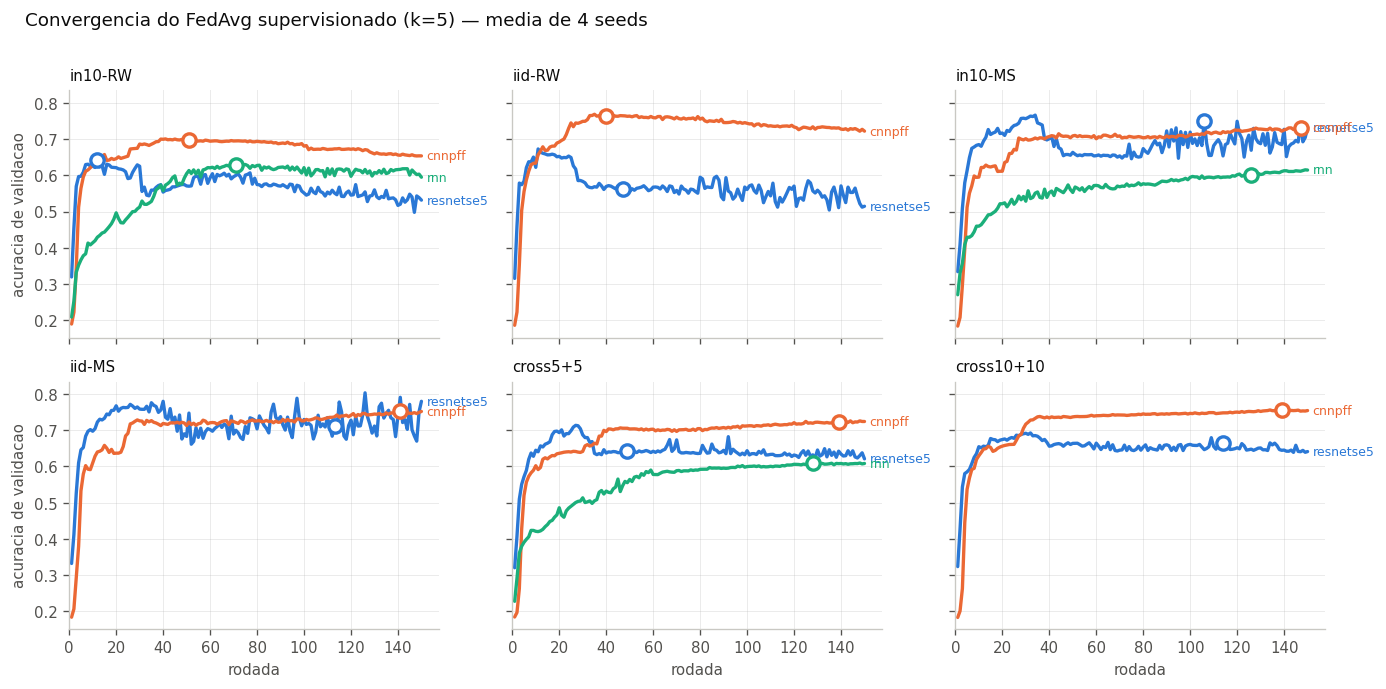

In [4]:
def plot_convergence(df):
    if df.empty:
        print('sem celula completa ainda — nada a plotar.')
        return
    arms = [a for a in ARM_ORDER if a in set(df.arm)]
    ncol = min(3, len(arms))
    nrow = int(np.ceil(len(arms) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.0 * ncol, 2.9 * nrow),
                             squeeze=False, sharex=True, sharey=True)
    sr = selected_rounds(df)
    for ax, arm in zip(axes.ravel(), arms):
        sub = df[df.arm == arm]
        for enc in ENCODERS:
            s = sub[sub.encoder == enc]
            if s.empty:
                continue
            curve = s.groupby(['seed', 'round'])['val_acc'].mean().groupby('round').mean()
            ax.plot(curve.index, curve.values, lw=2, color=COLOR[enc], label=enc,
                    solid_capstyle='round')
            br = int(sr[(sr.encoder == enc) & (sr.arm == arm)].best_round.median())
            if br in curve.index:
                ax.plot([br], [curve[br]], marker='o', ms=8, mfc='white',
                        mec=COLOR[enc], mew=2, zorder=5)
            # Rotulo direto: identidade nunca depende so da cor.
            ax.annotate(enc, (curve.index[-1], curve.values[-1]), fontsize=7.5,
                        color=COLOR[enc], xytext=(3, 0), textcoords='offset points',
                        va='center')
        ax.set_title(arm, fontsize=9, color=INK, loc='left')
        ax.set_xlim(left=0)
    for ax in axes.ravel()[len(arms):]:
        ax.set_visible(False)
    for ax in axes[-1]:
        ax.set_xlabel('rodada')
    for ax in axes[:, 0]:
        ax.set_ylabel('acuracia de validacao')
    fig.suptitle('Convergencia do FedAvg supervisionado (k=5) — media de 4 seeds',
                 fontsize=11, x=0.02, ha='left', color=INK)
    fig.tight_layout(rect=[0, 0, 0.97, 0.97])
    plt.show()


plot_convergence(full)

In [5]:
# Tabela equivalente da figura acima: quanto a validacao ainda ganhou no
# ultimo quinto das rodadas. Ganho positivo = a curva nao tinha convergido.
def convergence_table(df):
    if df.empty:
        return pd.DataFrame()
    r_max = int(df['round'].max())
    lo = int(r_max * 0.8)
    rows = []
    for (enc, arm, seed), s in df.groupby(['encoder', 'arm', 'seed']):
        c = s.groupby('round')['val_acc'].mean().sort_index()
        rows.append({'encoder': enc, 'arm': arm, 'seed': seed,
                     'ganho_ultimo_quinto': max(0.0, c.loc[lo:].max() - c.loc[:lo].max()),
                     'inclinacao_final': np.polyfit(c.loc[lo:].index, c.loc[lo:].values, 1)[0]})
    t = pd.DataFrame(rows)
    out = t.groupby('encoder').agg(
        ganho_ult_quinto_pp=('ganho_ultimo_quinto', lambda s: s.mean() * 100),
        runs_ainda_subindo=('ganho_ultimo_quinto', lambda s: int((s > 0.002).sum())),
        runs=('ganho_ultimo_quinto', 'size'),
        inclinacao_pp_10r=('inclinacao_final', lambda s: s.mean() * 1000))
    return out.round(2)


ct = convergence_table(full)
if not ct.empty:
    print('Inclinacao positiva e ganho no ultimo quinto = curva ainda subindo.')
    display(ct)

Inclinacao positiva e ganho no ultimo quinto = curva ainda subindo.


,ganho_ult_quinto_pp,runs_ainda_subindo,runs,inclinacao_pp_10r
encoder,,,,
cnnpff,0.53,15,24,-0.02
resnetse5,0.19,5,24,-0.28
rnn,0.31,5,12,0.18


## 5. Resultado principal

Acuracia de **teste** na rodada escolhida pela validacao, media +/- desvio sobre as
4 seeds, por alvo. Os bracos `cross*` tem dois alvos e aparecem duas vezes.

In [6]:
def main_table(ab):
    if ab.empty:
        return pd.DataFrame()
    t = ab.groupby(['arm', 'target', 'encoder'])['test_acc'].agg(['mean', 'std', 'size'])
    t = t.rename(columns={'mean': 'acc', 'std': 'dp', 'size': 'n'})
    return t.round(3)


mt = main_table(best)
if mt.empty:
    print('sem celula completa ainda.')
else:
    display(mt)

acc     dp  n
arm        target          encoder                   
cross10+10 MotionSense     cnnpff     0.828  0.012  4
                           resnetse5  0.877  0.040  4
           RealWorld_thigh cnnpff     0.704  0.031  4
                           resnetse5  0.647  0.041  4
cross5+5   MotionSense     cnnpff     0.776  0.028  4
                           resnetse5  0.801  0.043  4
                           rnn        0.602  0.033  4
           RealWorld_thigh cnnpff     0.651  0.029  4
                           resnetse5  0.647  0.037  4
                           rnn        0.592  0.019  4
iid-MS     MotionSense     cnnpff     0.846  0.007  4
                           resnetse5  0.905  0.024  4
iid-RW     RealWorld_thigh cnnpff     0.753  0.018  4
                           resnetse5  0.710  0.035  4
in10-MS    MotionSense     cnnpff     0.837  0.019  4
                           resnetse5  0.891  0.044  4
                           rnn        0.721  0.038  4
in10-RW    RealWorld_thigh cnnpff     0.701  0.018  4
                           resnetse5  0.680  0.058  4
                           rnn        0.589  0.051  4

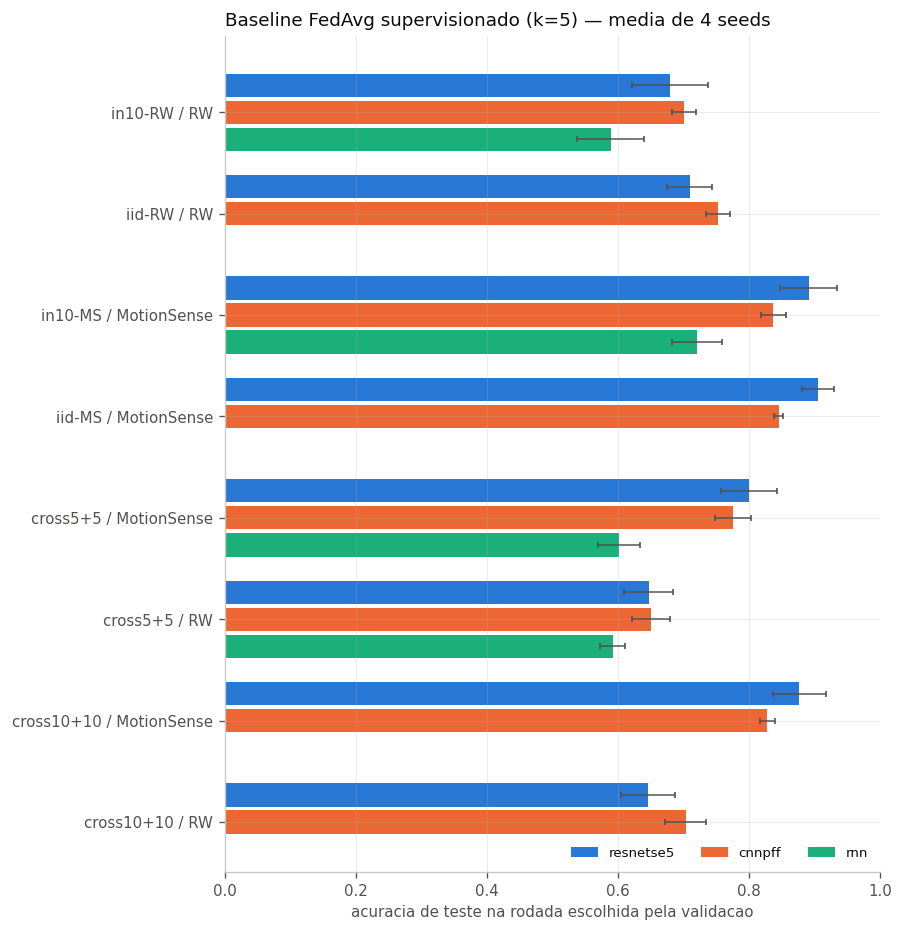

In [7]:
def plot_main(ab):
    if ab.empty:
        print('sem celula completa ainda — nada a plotar.')
        return
    g = ab.groupby(['arm', 'target', 'encoder'])['test_acc'].agg(['mean', 'std'])
    rows = [(a, t) for a in ARM_ORDER for t in sorted(set(ab[ab.arm == a].target))
            if (a, t) in {(x, y) for x, y, _ in g.index}]
    encs = [e for e in ENCODERS if e in set(ab.encoder)]
    fig, ax = plt.subplots(figsize=(7.6, 0.52 * len(rows) * max(1, len(encs)) / 2 + 1.6))
    h = 0.8 / max(1, len(encs))
    ypos = np.arange(len(rows))
    for j, enc in enumerate(encs):
        vals, errs = [], []
        for key in rows:
            k = (key[0], key[1], enc)
            vals.append(g['mean'][k] if k in g.index else np.nan)
            errs.append(g['std'][k] if k in g.index else np.nan)
        off = (j - (len(encs) - 1) / 2) * h
        ax.barh(ypos + off, vals, height=h * 0.86, color=COLOR[enc], label=enc,
                xerr=errs, error_kw=dict(ecolor=INK_2, lw=0.9, capsize=2))
    ax.set_yticks(ypos)
    ax.set_yticklabels(['%s / %s' % (a, t.replace('RealWorld_thigh', 'RW')) for a, t in rows])
    ax.invert_yaxis()
    ax.set_xlabel('acuracia de teste na rodada escolhida pela validacao')
    ax.set_xlim(0, 1)
    ax.legend(loc='lower right', ncol=len(encs), fontsize=8)
    ax.set_title('Baseline FedAvg supervisionado (k=5) — media de 4 seeds',
                 fontsize=11, loc='left', color=INK)
    fig.tight_layout()
    plt.show()


plot_main(best)

## 6. Os dois contrastes do desenho

Ambos sao **pareados por seed**: o Δ e a media das diferencas run a run, nao a
diferenca de duas medias. Quando os dois bracos nao tem as mesmas seeds, o Δ usa
a intersecao e a coluna `n` diz sobre quantos pares ele foi calculado.

- **Feature skew** = `device − iid`, mesmo alvo. Isola a heterogeneidade entre pessoas.
- **Domain shift** = `cross5+5 − in-domain de 10`, mesmo alvo e mesmo numero de clientes.

In [8]:
def paired_delta(ab, arm_a, arm_b, target):
    # Δ pareado por seed entre dois bracos, para cada encoder.
    out = []
    for enc in ENCODERS:
        s = ab[(ab.encoder == enc) & (ab.target == target)]
        x = s[s.arm == arm_a].set_index('seed')['test_acc']
        y = s[s.arm == arm_b].set_index('seed')['test_acc']
        common = x.index.intersection(y.index)
        if len(common) == 0:
            continue
        d = x[common] - y[common]
        out.append({'encoder': enc, 'alvo': target,
                    arm_a: round(x[common].mean(), 3), arm_b: round(y[common].mean(), 3),
                    'delta': round(d.mean(), 3), 'dp': round(d.std(), 3), 'n': len(common)})
    return pd.DataFrame(out)


PAIRS_SKEW = [('in10-RW', 'iid-RW', 'RealWorld_thigh'), ('in10-MS', 'iid-MS', 'MotionSense')]
PAIRS_SHIFT = [('cross5+5', 'in10-RW', 'RealWorld_thigh'), ('cross5+5', 'in10-MS', 'MotionSense')]


def delta_frame(ab, pairs):
    if ab.empty:
        return pd.DataFrame()
    fr = [paired_delta(ab, a, b, t) for a, b, t in pairs]
    fr = [f for f in fr if not f.empty]
    return pd.concat(fr, ignore_index=True) if fr else pd.DataFrame()


skew = delta_frame(best, PAIRS_SKEW)
shift = delta_frame(best, PAIRS_SHIFT)
if skew.empty and shift.empty:
    print('nenhum par de bracos completo ainda.')
else:
    print('Δ FEATURE SKEW (device - iid): negativo = particionar por usuario custa.')
    display(skew)
    print('\nΔ DOMAIN SHIFT (cross5+5 - in-domain): negativo = trocar metade dos clientes custa.')
    display(shift)

Δ FEATURE SKEW (device - iid): negativo = particionar por usuario custa.


,encoder,alvo,in10-RW,iid-RW,delta,dp,n,in10-MS,iid-MS
0,resnetse5,RealWorld_thigh,0.680,0.710,-0.030,0.029,4,NaN,NaN
1,cnnpff,RealWorld_thigh,0.701,0.753,-0.052,0.008,4,NaN,NaN
2,resnetse5,MotionSense,NaN,NaN,-0.014,0.036,4,0.891,0.905
3,cnnpff,MotionSense,NaN,NaN,-0.008,0.013,4,0.837,0.846



Δ DOMAIN SHIFT (cross5+5 - in-domain): negativo = trocar metade dos clientes custa.


,encoder,alvo,cross5+5,in10-RW,delta,dp,n,in10-MS
0,resnetse5,RealWorld_thigh,0.647,0.680,-0.032,0.054,4,NaN
1,cnnpff,RealWorld_thigh,0.651,0.701,-0.051,0.023,4,NaN
2,rnn,RealWorld_thigh,0.592,0.589,0.003,0.040,4,NaN
3,resnetse5,MotionSense,0.801,NaN,-0.091,0.031,4,0.891
4,cnnpff,MotionSense,0.776,NaN,-0.061,0.019,4,0.837
5,rnn,MotionSense,0.602,NaN,-0.119,0.033,4,0.721


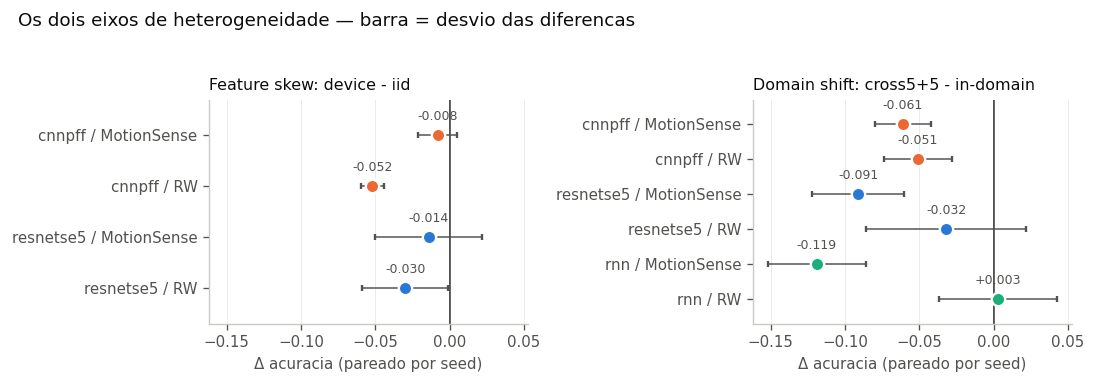

In [9]:
def plot_deltas(frames_labels):
    frames_labels = [(f, lab) for f, lab in frames_labels if not f.empty]
    if not frames_labels:
        print('sem Δ calculavel ainda — nada a plotar.')
        return
    fig, axes = plt.subplots(1, len(frames_labels), figsize=(4.6 * len(frames_labels), 3.2),
                             squeeze=False, sharex=True)
    for ax, (f, lab) in zip(axes[0], frames_labels):
        f = f.copy()
        f['row'] = f.encoder + ' / ' + f.alvo.str.replace('RealWorld_thigh', 'RW', regex=False)
        f = f.sort_values('row', ascending=False).reset_index(drop=True)
        y = np.arange(len(f))
        ax.axvline(0, color=INK_2, lw=1.2, zorder=1)
        for i, r in f.iterrows():
            ax.errorbar(r['delta'], y[i], xerr=r['dp'], fmt='o', ms=8,
                        color=COLOR[r['encoder']], ecolor=INK_2, elinewidth=0.9,
                        capsize=2, mec='white', mew=1.4, zorder=3)
            ax.annotate('%+.3f' % r['delta'], (r['delta'], y[i]), fontsize=7.5,
                        color=INK_2, xytext=(0, 9), textcoords='offset points', ha='center')
        ax.set_yticks(y)
        ax.set_yticklabels(f['row'])
        ax.set_ylim(-0.7, len(f) - 0.3)
        ax.set_title(lab, fontsize=9.5, loc='left', color=INK)
        ax.set_xlabel('Δ acuracia (pareado por seed)')
        ax.grid(axis='y', alpha=0)
    fig.suptitle('Os dois eixos de heterogeneidade — barra = desvio das diferencas',
                 fontsize=11, x=0.02, ha='left', color=INK)
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()


plot_deltas([(skew, 'Feature skew: device - iid'),
             (shift, 'Domain shift: cross5+5 - in-domain')])

## 7. Custo de comunicacao

`uplink_mb` e por rodada (soma sobre os clientes). O custo ate a rodada escolhida e
o que o braco efetivamente gastou para chegar ao numero reportado — e o eixo em que
o Fed-SSL tera de ser comparado tambem.

In [10]:
def comm_cost(ab):
    if ab.empty:
        return pd.DataFrame()
    one = ab.drop_duplicates(subset=['encoder', 'arm', 'seed'])
    one = one.assign(total_uplink_gb=one.uplink_mb * one.best_round / 1024)
    t = one.groupby(['encoder', 'arm']).agg(
        rodada=('best_round', 'mean'),
        mb_por_rodada=('uplink_mb', 'first'),
        uplink_ate_selecao_gb=('total_uplink_gb', 'mean'))
    return t.round(2)


cc = comm_cost(best)
if cc.empty:
    print('sem celula completa ainda.')
else:
    display(cc)

rodada  mb_por_rodada  uplink_ate_selecao_gb
encoder   arm                                                     
cnnpff    cross10+10  140.25          11.13                   1.52
          cross5+5    117.00           5.56                   0.64
          iid-MS      136.50           5.56                   0.74
          iid-RW       47.25           5.56                   0.26
          in10-MS     142.75           5.56                   0.78
          in10-RW      61.25           5.56                   0.33
resnetse5 cross10+10  102.00          10.46                   1.04
          cross5+5     54.25           5.23                   0.28
          iid-MS      104.50           5.23                   0.53
          iid-RW       58.25           5.23                   0.30
          in10-MS      98.75           5.23                   0.50
          in10-RW      14.75           5.23                   0.08
rnn       cross5+5    115.75           6.52                   0.74
          in10-MS     110.50           6.52                   0.70
          in10-RW      84.50           6.52                   0.54

## 8. Leitura

Preencher conforme a grade fecha. Perguntas que este notebook responde:

1. **`R` bastou?** Secao 4 — inclinacao final positiva ou runs `no_teto` > 0
   significam que o numero daquele encoder e um piso, nao um teto.
2. **Feature skew importa?** Secao 6, painel esquerdo — se o Δ troca de sinal
   entre encoders e o desvio cobre o zero, o controle deu nulo e a particao por
   usuario dentro de um mesmo dataset nao e um regime non-IID dificil.
3. **Quanto custa o domain shift?** Secao 6, painel direito — e o eixo que o
   Fed-SSL precisa atacar.

### O que este notebook nao responde

Nao ha comparacao com Fed-SSL aqui: este e o contrafactual, medido sozinho. A
comparacao entra em notebook proprio quando o braco Fed-SSL existir.